# Детекция лиц: каскад Хаара и нейросеть YuNet

Всё в ячейках. Картинки показываем через matplotlib —
**никаких `cv2.imshow`**, оно в ноутбуке зависает.

## 1. Импорты

In [2]:
%matplotlib inline
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 8)
print('OpenCV:', cv2.__version__)

OpenCV: 4.12.0


## 2. Функция показа

OpenCV хранит цвет как **BGR**, matplotlib ждёт **RGB**.
Без конвертации лица будут синими.

In [3]:
def show(img, title='', size=(12, 8)):
    plt.figure(figsize=size)
    if len(img.shape) == 2:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

## 3. Загружаем фото

Положи своё фото в `images/` и поменяй имя ниже.

размер: (2560, 1703, 3) -> (высота, ширина, каналы)


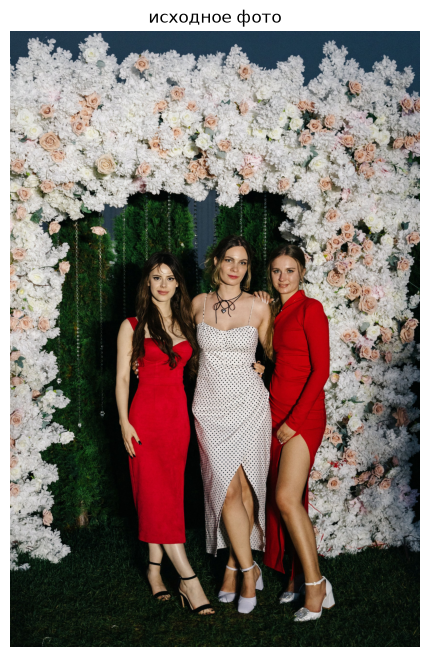

In [4]:
PHOTO = 'images/631_resized.jpeg'

img = cv2.imread(PHOTO)
print('размер:', img.shape, '-> (высота, ширина, каналы)')
show(img, 'исходное фото')

## 4. Картинка — это массив чисел

In [5]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

print('цветное:', img.shape, '=', img.size, 'чисел')
print('серое:  ', gray.shape, '=', gray.size, 'чисел')
print()
print('кусочек 5x5 пикселей (яркость 0..255):')
print(gray[500:505, 500:505])

цветное: (2560, 1703, 3) = 13079040 чисел
серое:   (2560, 1703) = 4359680 чисел

кусочек 5x5 пикселей (яркость 0..255):
[[216 220 222 221 222]
 [221 222 216 207 224]
 [222 223 217 208 224]
 [222 224 225 223 222]
 [222 223 228 220 206]]


## 5. Подготовка для Хаара

1. убираем цвет
2. `equalizeHist` растягивает контраст

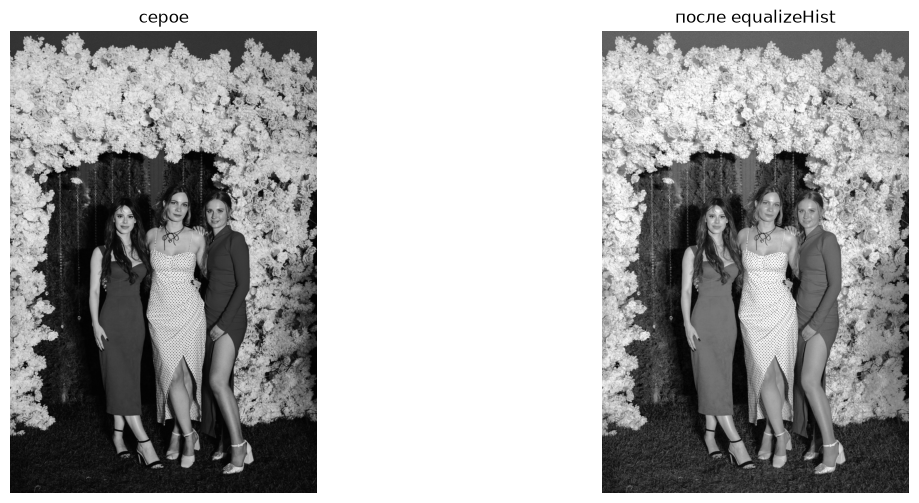

до:    min=0 max=255
после: min=0 max=255


In [6]:
gray_eq = cv2.equalizeHist(gray)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].imshow(gray, cmap='gray')
ax[0].set_title('серое')
ax[0].axis('off')
ax[1].imshow(gray_eq, cmap='gray')
ax[1].set_title('после equalizeHist')
ax[1].axis('off')
plt.show()

print('до:    min=%d max=%d' % (gray.min(), gray.max()))
print('после: min=%d max=%d' % (gray_eq.min(), gray_eq.max()))

## 6. Каскад Хаара

In [7]:
cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)
print('каскад загружен:', not cascade.empty())

faces = cascade.detectMultiScale(
    gray_eq,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30),
)
print('найдено:', len(faces))

каскад загружен: True
найдено: 14


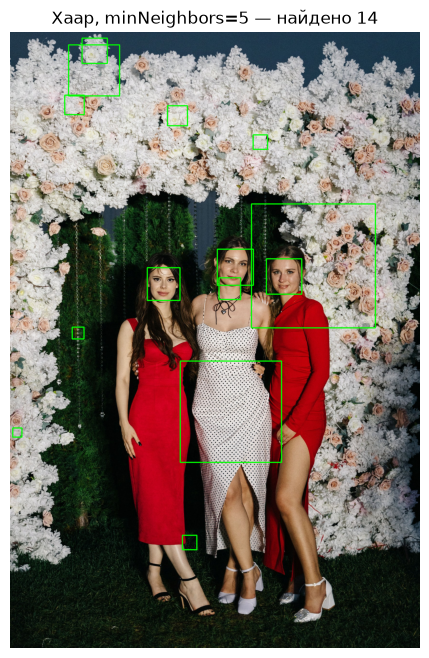

In [8]:
out = img.copy()
for (x, y, w, h) in faces:
    cv2.rectangle(out, (x, y), (x + w, y + h), (0, 255, 0), 4)

show(out, 'Хаар, minNeighbors=5 — найдено %d' % len(faces))

## 7. Крутим minNeighbors

In [9]:
for mn in (5, 8, 10, 12, 20):
    f = cascade.detectMultiScale(gray_eq, scaleFactor=1.1,
                                 minNeighbors=mn, minSize=(30, 30))
    print('minNeighbors=%2d -> найдено %2d' % (mn, len(f)))

minNeighbors= 5 -> найдено 14
minNeighbors= 8 -> найдено  7
minNeighbors=10 -> найдено  4
minNeighbors=12 -> найдено  3
minNeighbors=20 -> найдено  3


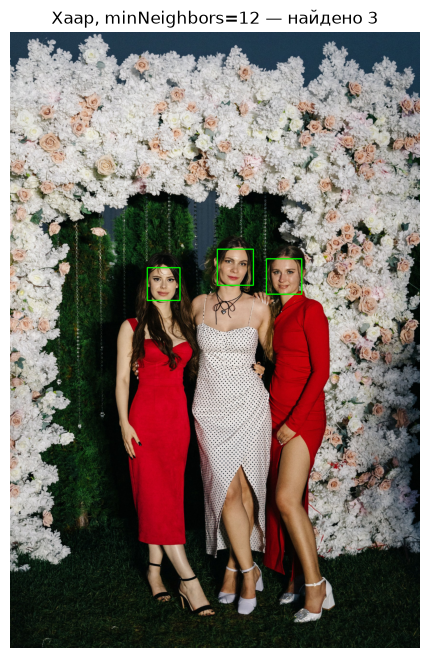

In [10]:
faces_clean = cascade.detectMultiScale(gray_eq, scaleFactor=1.1,
                                       minNeighbors=12, minSize=(30, 30))
out = img.copy()
for (x, y, w, h) in faces_clean:
    cv2.rectangle(out, (x, y), (x + w, y + h), (0, 255, 0), 4)

show(out, 'Хаар, minNeighbors=12 — найдено %d' % len(faces_clean))

## 8. YuNet — нейросеть

Главное отличие: выдаёт **уверенность**.

In [11]:
h, w = img.shape[:2]

detector = cv2.FaceDetectorYN.create(
    'models/yunet.onnx',
    '',
    (w, h),
    0.8,
    0.3,
    5000,
)
detector.setInputSize((w, h))

_, yunet_faces = detector.detect(img)
print('найдено:', len(yunet_faces))

найдено: 3


### Что внутри результата: 15 чисел на находку

In [12]:
f = yunet_faces[0]
names = ['x', 'y', 'ширина', 'высота',
         'прав.глаз X', 'прав.глаз Y', 'лев.глаз X', 'лев.глаз Y',
         'нос X', 'нос Y', 'прав.рот X', 'прав.рот Y',
         'лев.рот X', 'лев.рот Y', 'УВЕРЕННОСТЬ']

for i, (v, n) in enumerate(zip(f, names)):
    print('%2d | %8.2f | %s' % (i, v, n))

 0 |  1078.98 | x
 1 |   940.39 | y
 2 |   124.42 | ширина
 3 |   152.63 | высота
 4 |  1111.27 | прав.глаз X
 5 |  1004.87 | прав.глаз Y
 6 |  1167.70 | лев.глаз X
 7 |  1002.46 | лев.глаз Y
 8 |  1138.43 | нос X
 9 |  1032.42 | нос Y
10 |  1115.36 | прав.рот X
11 |  1054.10 | прав.рот Y
12 |  1165.81 | лев.рот X
13 |  1052.27 | лев.рот Y
14 |     0.94 | УВЕРЕННОСТЬ


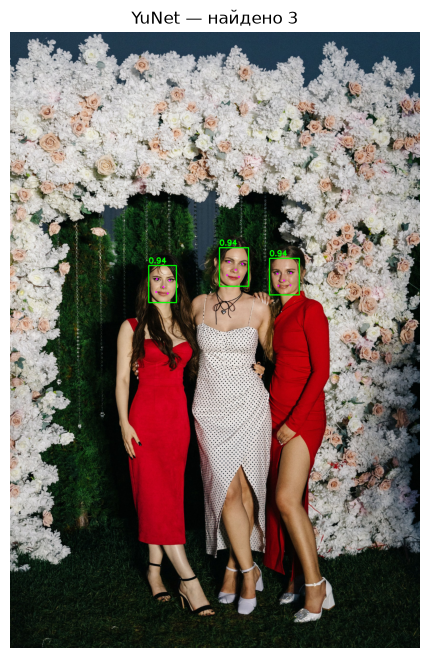

In [13]:
out = img.copy()
thick = max(2, w // 500)

for f in yunet_faces:
    x, y, bw, bh = [int(v) for v in f[:4]]
    conf = float(f[14])
    color = (0, 255, 0) if conf > 0.9 else (0, 165, 255)
    cv2.rectangle(out, (x, y), (x + bw, y + bh), color, thick)
    cv2.putText(out, '%.2f' % conf, (x, max(20, y - 10)),
                cv2.FONT_HERSHEY_SIMPLEX, thick * 0.35, color, thick)
    for i in range(5):
        cv2.circle(out, (int(f[4 + i * 2]), int(f[5 + i * 2])),
                   thick + 1, (255, 0, 255), -1)

show(out, 'YuNet — найдено %d' % len(yunet_faces))

## 9. Порог уверенности

In [14]:
for th in (0.3, 0.5, 0.6, 0.8, 0.9):
    d = cv2.FaceDetectorYN.create('models/yunet.onnx', '', (w, h), th, 0.3, 5000)
    d.setInputSize((w, h))
    _, ff = d.detect(img)
    n = 0 if ff is None else len(ff)
    confs = '' if ff is None else ' '.join('%.2f' % r[14] for r in ff)
    print('порог %.2f -> %2d находок | %s' % (th, n, confs[:60]))

порог 0.30 -> 20 находок | 0.94 0.94 0.94 0.72 0.51 0.49 0.46 0.44 0.43 0.41 0.40 0.40 
порог 0.50 ->  5 находок | 0.94 0.94 0.94 0.72 0.51
порог 0.60 ->  4 находок | 0.94 0.94 0.94 0.72
порог 0.80 ->  3 находок | 0.94 0.94 0.94
порог 0.90 ->  3 находок | 0.94 0.94 0.94


## 10. Сравнение бок о бок

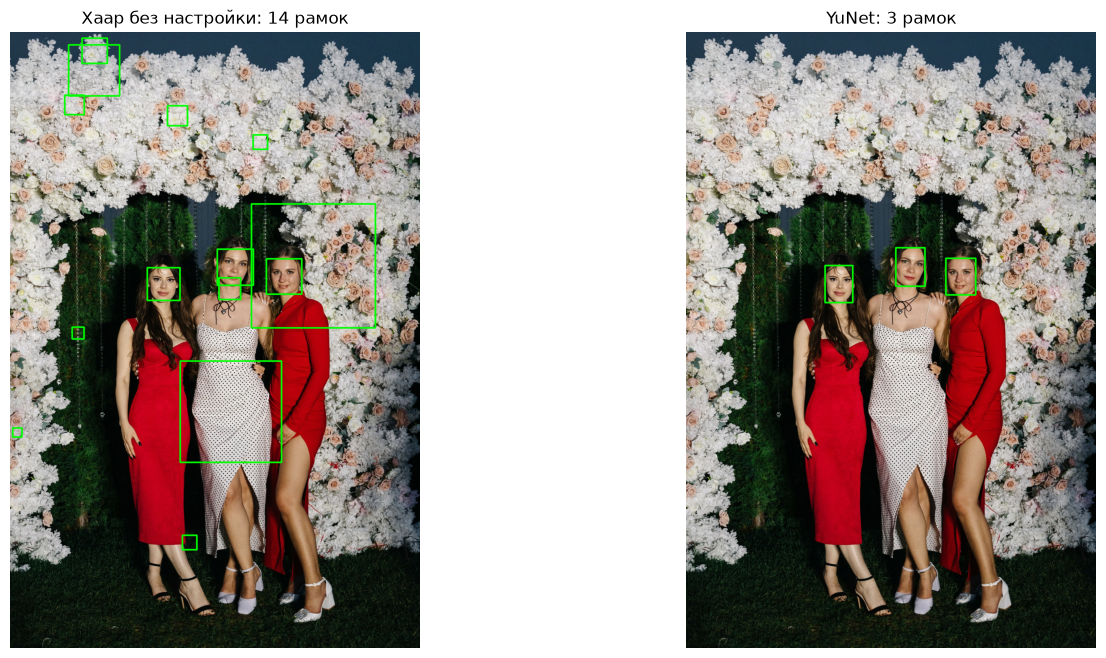

In [15]:
a = img.copy()
for (x, y, bw, bh) in faces:
    cv2.rectangle(a, (x, y), (x + bw, y + bh), (0, 255, 0), 5)

b = img.copy()
for f in yunet_faces:
    x, y, bw, bh = [int(v) for v in f[:4]]
    cv2.rectangle(b, (x, y), (x + bw, y + bh), (0, 255, 0), 5)

fig, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].imshow(cv2.cvtColor(a, cv2.COLOR_BGR2RGB))
ax[0].set_title('Хаар без настройки: %d рамок' % len(faces))
ax[0].axis('off')
ax[1].imshow(cv2.cvtColor(b, cv2.COLOR_BGR2RGB))
ax[1].set_title('YuNet: %d рамок' % len(yunet_faces))
ax[1].axis('off')
plt.show()

---
# 11. Веб-камера

⚠️ **Видео в ноутбуке работает не так, как фото.**

`cv2.imshow` в ноутбуке **зависает** — окно не отрисуется, ядро повиснет.
Поэтому здесь два подхода:

| способ | как | когда |
|---|---|---|
| **снимок** | захватить один кадр, показать через matplotlib | ✅ в ноутбуке |
| **живое видео** | отдельное окно `cv2.imshow` в цикле | ⚠️ только из терминала |

Ниже — первый способ. Для живого видео есть скрипт `detect_webcam_yunet.py`.

## 11.1. Один снимок с камеры

Открываем камеру, берём кадр, сразу закрываем.

⚠️ **macOS спросит разрешение на камеру** при первом запуске.
Разрешение выдаётся приложению (VS Code), а не Python.

In [ ]:
cap = cv2.VideoCapture(0)      # 0 = встроенная камера

if not cap.isOpened():
    print('Камера не открылась!')
    print('Системные настройки -> Конфиденциальность -> Камера -> разреши VS Code')
else:
    ok, frame = cap.read()
    cap.release()              # освобождаем СРАЗУ, иначе камера останется занятой

    if ok:
        frame = cv2.flip(frame, 1)         # зеркалим, как в зеркале
        print('кадр получен:', frame.shape)
        show(frame, 'снимок с камеры')
    else:
        print('Кадр не получен')

## 11.2. Ищем лицо на снимке

In [ ]:
h_cam, w_cam = frame.shape[:2]

det = cv2.FaceDetectorYN.create('models/yunet.onnx', '', (w_cam, h_cam), 0.8, 0.3, 5000)
det.setInputSize((w_cam, h_cam))
_, cam_faces = det.detect(frame)
cam_faces = cam_faces if cam_faces is not None else []

out = frame.copy()
for f in cam_faces:
    x, y, bw, bh = [int(v) for v in f[:4]]
    cv2.rectangle(out, (x, y), (x + bw, y + bh), (0, 255, 0), 2)
    cv2.putText(out, '%.2f' % f[14], (x, max(20, y - 8)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    for i in range(5):
        cv2.circle(out, (int(f[4 + i*2]), int(f[5 + i*2])), 3, (255, 0, 255), -1)

print('найдено лиц:', len(cam_faces))
show(out, 'YuNet на снимке с камеры')

## 11.3. Сколько кадров в секунду успевает детектор

Для плавного видео нужно **25+ fps**.

In [ ]:
import time

test = cv2.resize(frame, (640, 480))       # типичное разрешение вебки
th, tw = test.shape[:2]

# Хаар
t = time.time()
for _ in range(30):
    g = cv2.equalizeHist(cv2.cvtColor(test, cv2.COLOR_BGR2GRAY))
    cascade.detectMultiScale(g, scaleFactor=1.2, minNeighbors=5, minSize=(60, 60))
haar_ms = (time.time() - t) / 30 * 1000

# YuNet
d2 = cv2.FaceDetectorYN.create('models/yunet.onnx', '', (tw, th), 0.8, 0.3, 5000)
d2.setInputSize((tw, th))
t = time.time()
for _ in range(30):
    d2.detect(test)
yunet_ms = (time.time() - t) / 30 * 1000

print('Хаар : %6.1f мс на кадр -> %5.1f fps' % (haar_ms, 1000 / haar_ms))
print('YuNet: %6.1f мс на кадр -> %5.1f fps' % (yunet_ms, 1000 / yunet_ms))

## 11.4. Живое видео

В ноутбуке живое видео показать нельзя — нужен отдельный скрипт.

Открой **терминал** и запусти:

```bash
cd "/Users/dashanalivayko/Desktop/Data Science/data-science/lessons/face_detection"
../../../.venv/bin/python detect_webcam_yunet.py
```

**Клавиши в окне:**
- `h` — переключиться на каскад Хаара
- `y` — переключиться на YuNet
- `q` или `Esc` — выход

**Что попробовать:**
1. Поверни голову вбок — Хаар потеряет лицо, YuNet удержит
2. Наклони голову — то же самое
3. Закрой пол-лица рукой
4. Отойди подальше — при `minSize=(60,60)` Хаар перестанет видеть

Переключайся между `h` и `y` и сравнивай.

## Итог

| | Хаар | YuNet |
|---|---|---|
| год | 2001 | 2023 |
| признаки | придумал человек | сеть выучила сама |
| результат | да / нет | **уверенность 0..1** |
| наклон головы | теряет | находит |
| ключевые точки | нет | 5 штук |

**Главное:** Хаар требует подбирать `minNeighbors` под каждое фото.
У YuNet порог уверенности осмыслен и работает одинаково везде.